# Canonical decomposition — ablation overview

Reads the per-`(dataset, scene, config)` `results.json` written by
`scripts/canonical_decomp_batch.py` (under `results/canonical_ablation/`) and

1. plots an **overview** comparing the config ablations across datasets
   (point / infinite / mit) for recon / albedo / roughness / metallic / lighting /
   relighting RMSE;
2. for a chosen `(dataset, scene, config)`, renders **on demand** (via
   `scripts/canonical_relight_render.py`) the relight **comparison panels** (SH3 and a
   sharp Env-map highlight) and the two relight **videos** (Env-sharp + SH3, azimuth
   −45→45 at elevation 45), and displays them inline.

> `lighting_sh_rmse` exists only where there is GT SH lighting (**infinite**). MIT uses
> Marigold predictions as the intrinsic reference, so its albedo/roughness/metallic RMSE
> are measured against Marigold, not true GT.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "idr").is_dir())
os.chdir(REPO)
for p in (str(REPO), str(REPO / "scripts")):
    if p not in sys.path: sys.path.insert(0, p)
os.environ.setdefault("WANDB_MODE", "disabled")

from idr.paths import RESULTS_DIR
RESULTS_ROOT = RESULTS_DIR / "canonical_ablation"
DEVICE = "cuda"
print("results root:", RESULTS_ROOT)

results root: /home/felix/Projects/image-intrinsics/results/canonical_ablation


## 1. Load every run's `results.json`

In [3]:
def load_results(root=RESULTS_ROOT):
    rows = []
    for p in sorted(Path(root).glob("*/*/*/results.json")):
        r = json.loads(p.read_text())
        row = dict(dataset=r["dataset"], scene=r["scene"], config=r["config"],
                   run_dir=r["out_dir"], scene_dir=r["scene_dir"],
                   ds=int(r["cfg"].get("downsample", 1) or 1),
                   has_gt_lighting=r.get("has_gt_lighting"))
        row.update({k: r["metrics"].get(k) for k in
                    ("recon_rmse","albedo_rmse","roughness_rmse","metallic_rmse",
                     "lighting_sh_rmse","relighting_rmse")})
        rows.append(row)
    df = pd.DataFrame(rows)
    if df.empty:
        raise SystemExit(f"no results.json under {root} — run scripts/canonical_decomp_batch.py first")
    return df

df = load_results()
print(f"{len(df)} run(s) | datasets={sorted(df.dataset.unique())} | configs={sorted(df.config.unique())}")
df.groupby(['dataset','config']).size().unstack(fill_value=0)

3591 run(s) | datasets=['ct_sh_env', 'infinite', 'mit', 'point', 'point_no_shadow'] | configs=['base', 'light_mono', 'metallic_binarize', 'metallic_l1_1e-2', 'metallic_l1_1e-2_tv1e-3', 'metallic_l1_1e-2_tv1e-3_light_mono', 'metallic_l1_1e-2_tv1e-3_light_mono_sh2', 'metallic_l1_1e-2_tv1e-3_sigmoid', 'metallic_l1_1e-3', 'sh2', 'sigmoid', 'sparse', 'tv1e-4', 'tv1e-5', 'varpro']


config,base,light_mono,metallic_binarize,metallic_l1_1e-2,metallic_l1_1e-2_tv1e-3,metallic_l1_1e-2_tv1e-3_light_mono,metallic_l1_1e-2_tv1e-3_light_mono_sh2,metallic_l1_1e-2_tv1e-3_sigmoid,metallic_l1_1e-3,sh2,sigmoid,sparse,tv1e-4,tv1e-5,varpro
dataset,,,,,,,,,,,,,,,
ct_sh_env,67,67,67,67,67,67,67,67,67,67,67,67,67,67,67
infinite,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
mit,30,30,30,30,30,30,30,30,30,30,30,30,30,30,6
point,67,67,67,67,67,67,67,67,67,67,67,67,67,67,67
point_no_shadow,67,67,67,67,67,67,67,67,67,67,67,67,67,67,67


## 2. Overview — config ablations per dataset

Bars are the mean over scenes; error bars ±1 std. Missing bars = metric not available for
that dataset (e.g. lighting for MIT/point).

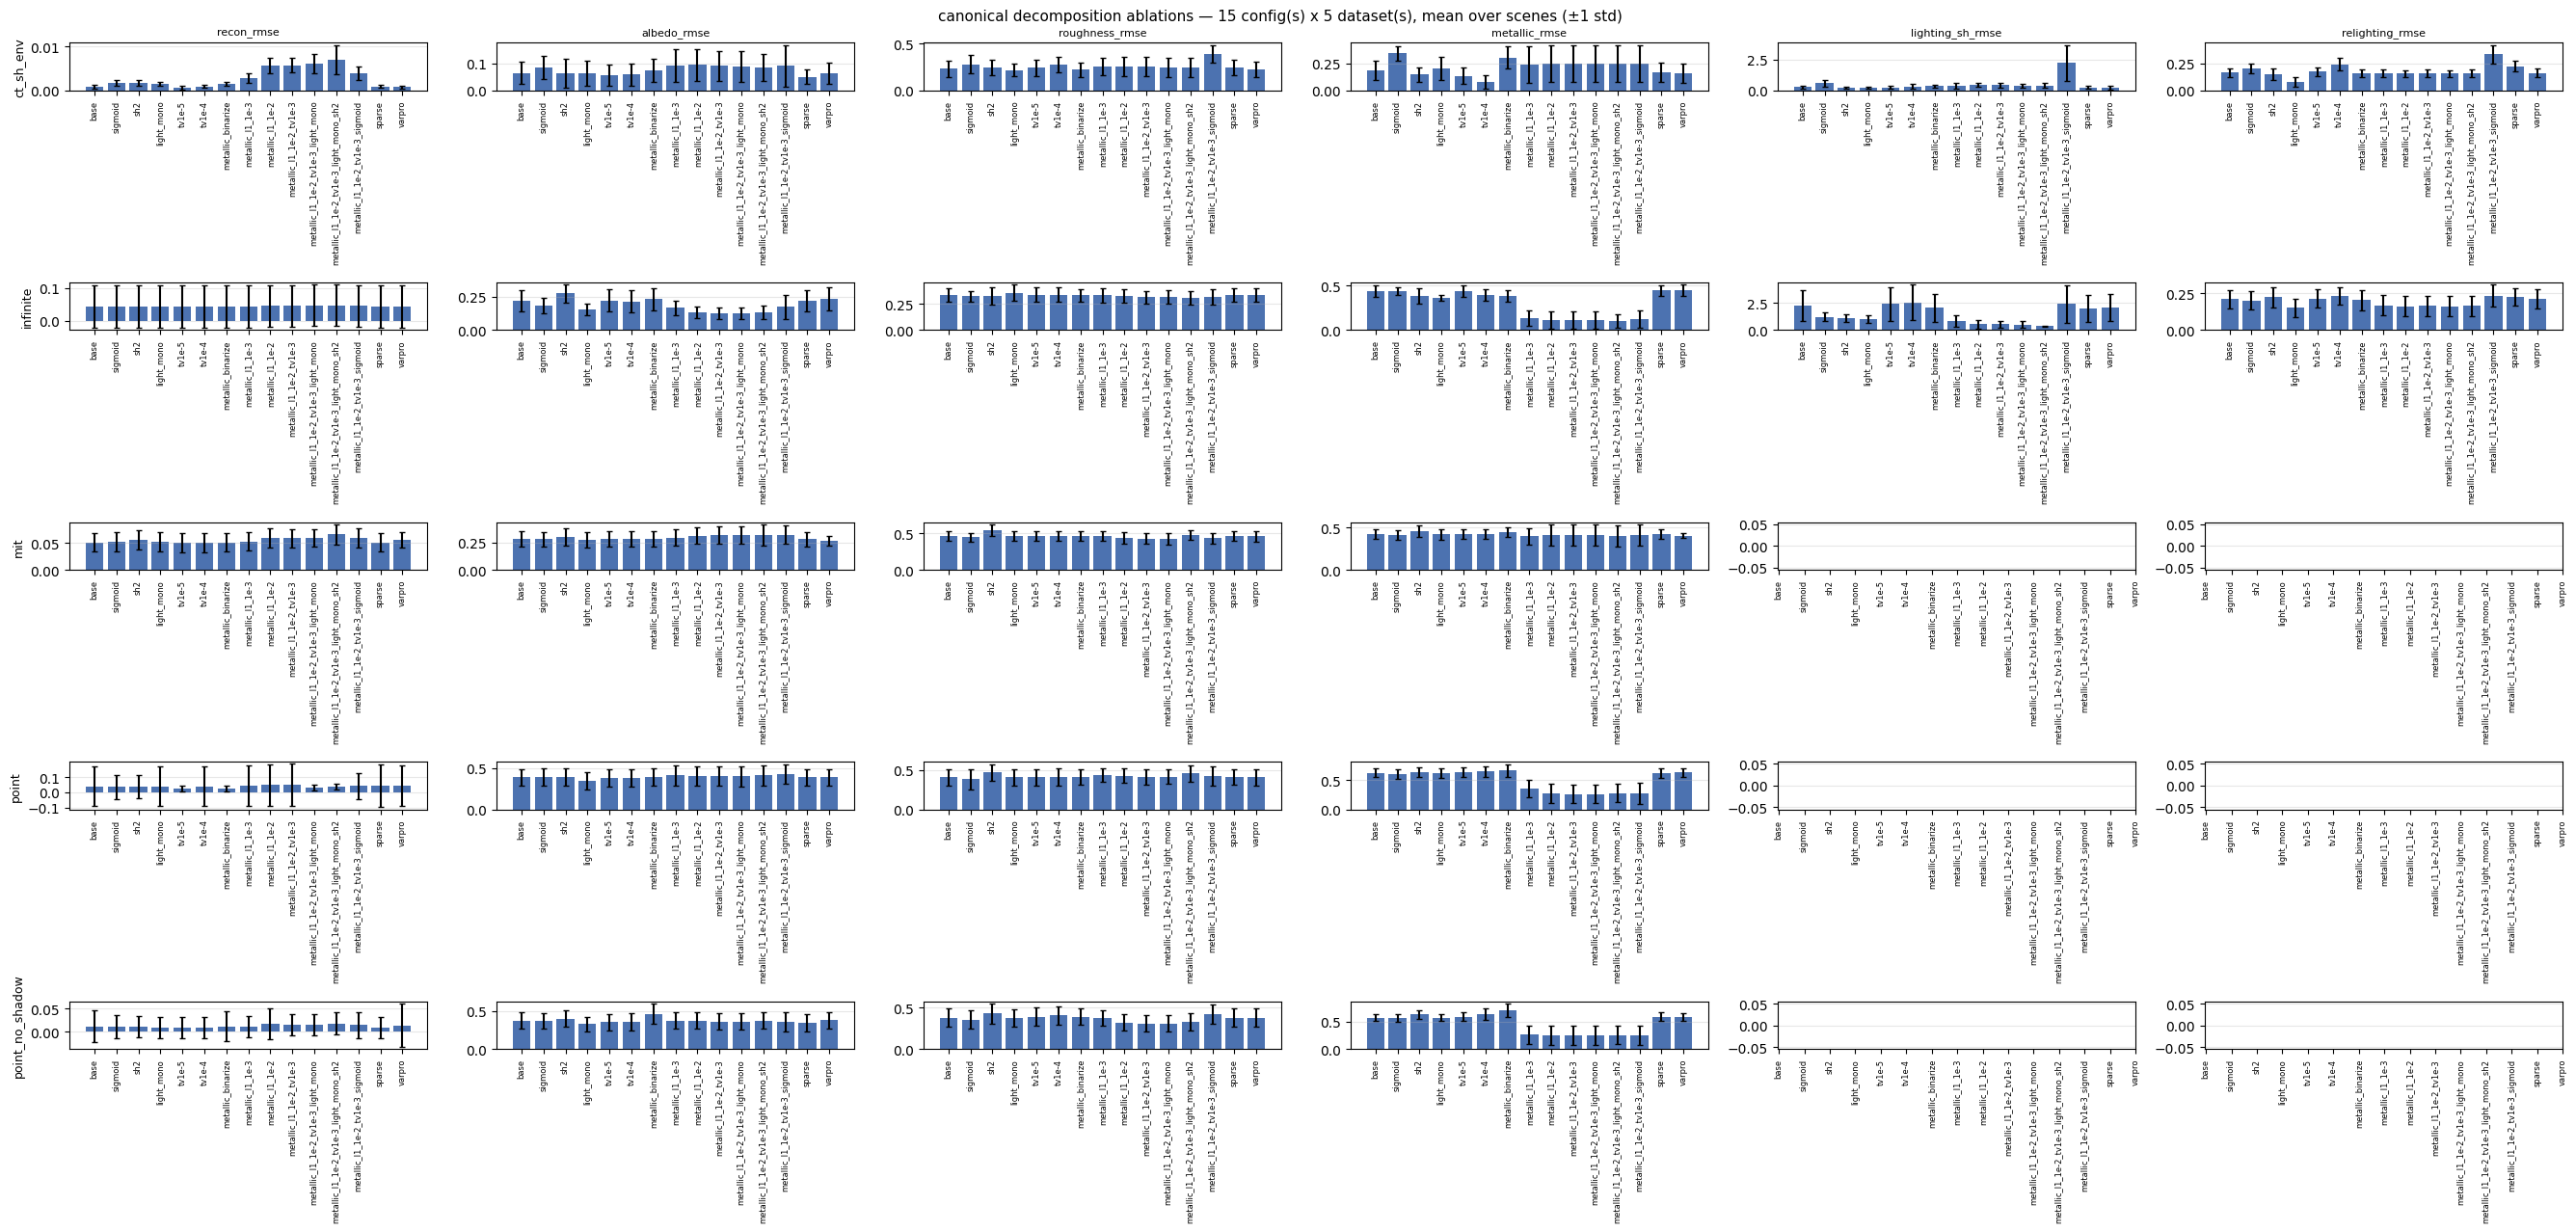

In [4]:
METRICS = ["recon_rmse","albedo_rmse","roughness_rmse","metallic_rmse",
           "lighting_sh_rmse","relighting_rmse"]

def config_order(present):
    """Canonical order from the batch script, then any EXTRA computed configs appended, so
    the overview always shows every variant that was actually run."""
    try:
        from canonical_decomp_batch import CONFIGS as _CFGS
        known = list(_CFGS)
    except Exception:
        known = ["base","sigmoid","sh2","light_mono","varpro","tv1e-5","tv1e-4",
                 "metallic_binarize","metallic_l1_1e-3","metallic_l1_1e-2","sparse"]
    return [c for c in known if c in present] + [c for c in sorted(present) if c not in known]

def overview(df, metrics=METRICS):
    metrics  = [m for m in metrics if m in df.columns]          # only computed metrics
    datasets = sorted(df.dataset.unique())                       # dynamic
    configs  = config_order(set(df.config))                      # dynamic (all variants)
    x = np.arange(len(configs))
    per_w = max(2.4, 0.30*len(configs))
    fig, axes = plt.subplots(len(datasets), len(metrics),
                             figsize=(per_w*len(metrics), 2.6*len(datasets)), squeeze=False)
    for ri, dset in enumerate(datasets):
        sub = df[df.dataset == dset]
        for ci, met in enumerate(metrics):
            ax = axes[ri][ci]
            means = [sub[sub.config==c][met].mean() for c in configs]
            stds  = [sub[sub.config==c][met].std()  for c in configs]
            ax.bar(x, means, yerr=stds, capsize=2, color="#4C72B0")
            ax.set_xticks(x); ax.set_xticklabels(configs, rotation=90, fontsize=6)
            if ri == 0: ax.set_title(met, fontsize=8)
            if ci == 0: ax.set_ylabel(dset, fontsize=9)
            ax.grid(axis="y", alpha=0.3)
    fig.suptitle(f"canonical decomposition ablations — {len(configs)} config(s) x "
                 f"{len(datasets)} dataset(s), mean over scenes (±1 std)", fontsize=11)
    plt.tight_layout(); plt.show()

overview(df)

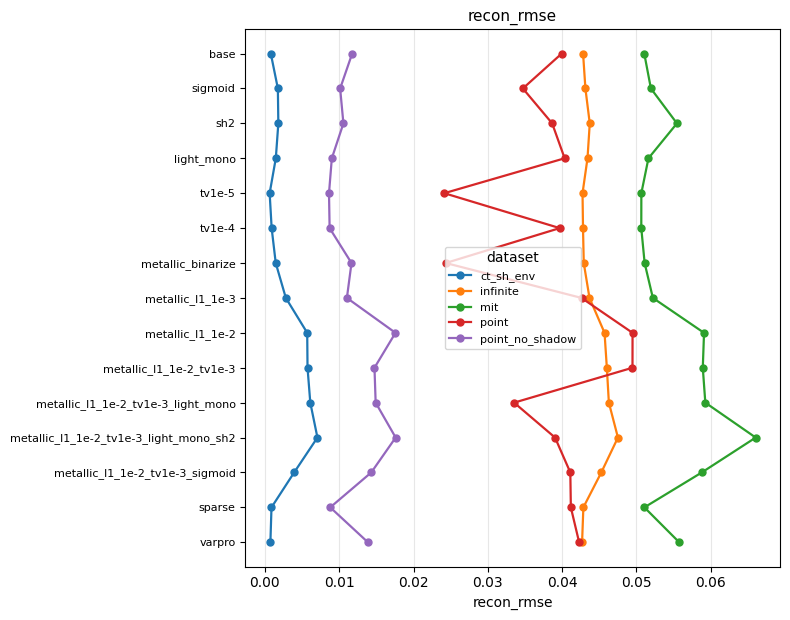

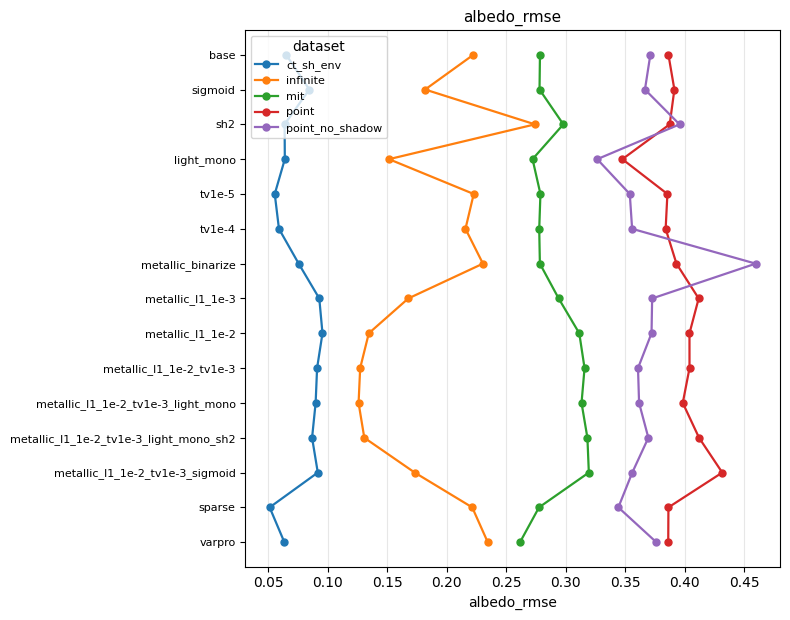

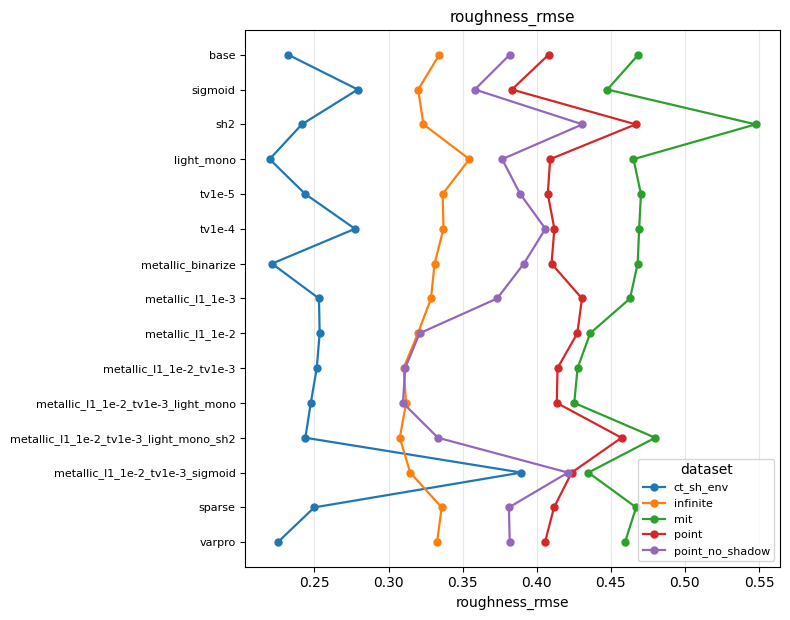

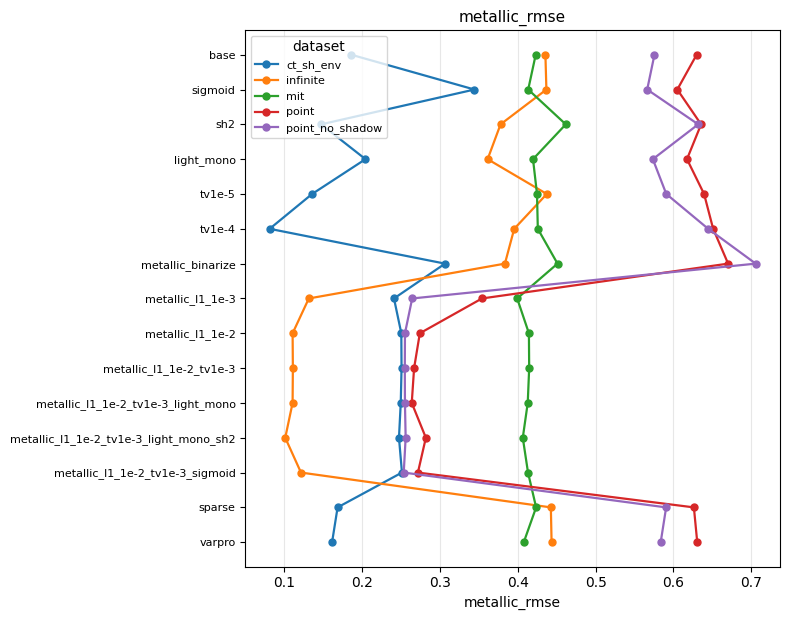

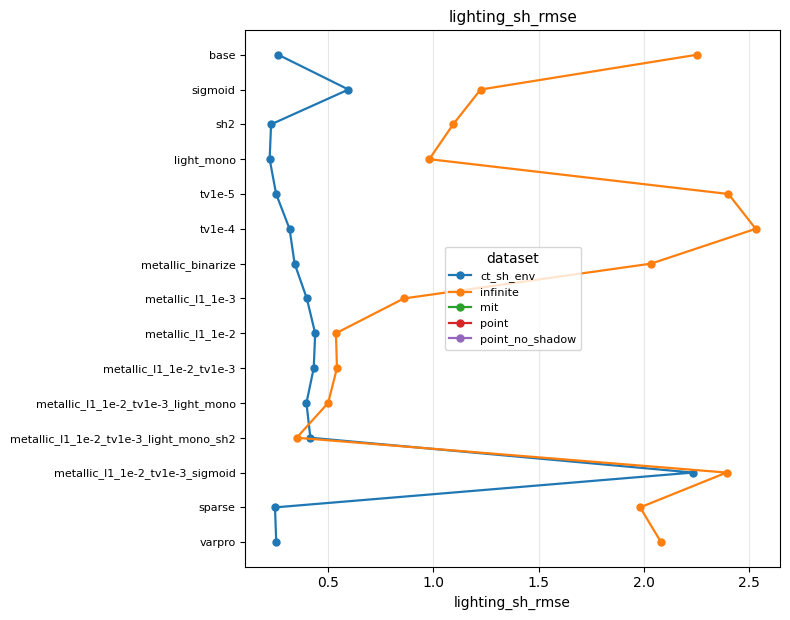

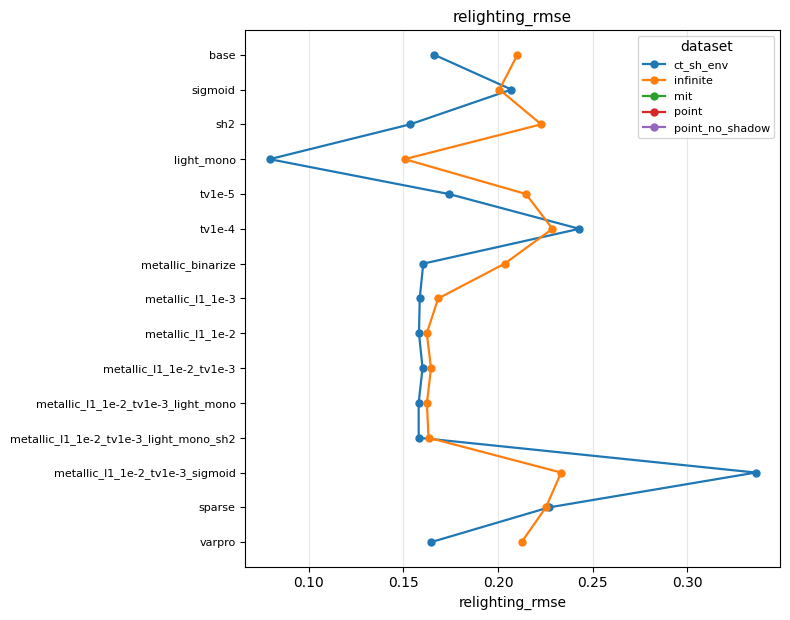

In [5]:
# One plot per metric: y = config, grouped by dataset.
#   kind="bars"  -> grouped horizontal bar chart
#   kind="lines" -> each dataset is points connected by a line across the configs
def per_metric_hbars(df, metrics=METRICS, kind="bars"):
    metrics  = [m for m in metrics if m in df.columns]
    datasets = sorted(df.dataset.unique())
    configs  = config_order(set(df.config))
    y        = np.arange(len(configs))
    h        = 0.8 / max(len(datasets), 1)
    colors   = plt.get_cmap("tab10")(np.linspace(0, 1, 10))
    for met in metrics:
        fig, ax = plt.subplots(figsize=(8, max(2.6, 0.42 * len(configs))))
        for di, dset in enumerate(datasets):
            means = np.array([df[(df.dataset == dset) & (df.config == c)][met].mean() for c in configs])
            if kind == "lines":
                ax.plot(means, y, marker="o", ms=5, lw=1.6, label=dset, color=colors[di % 10])
            else:
                ax.barh(y + di * h, means, height=h, label=dset, color=colors[di % 10])
        ax.set_yticks(y if kind == "lines" else y + h * (len(datasets) - 1) / 2)
        ax.set_yticklabels(configs, fontsize=8)
        ax.invert_yaxis()                                   # first config on top
        ax.set_xlabel(met); ax.set_title(met, fontsize=11)
        ax.grid(axis="x", alpha=0.3)
        ax.legend(fontsize=8, title="dataset")
        plt.tight_layout(); plt.show()

KIND = "lines"                                              # "bars" or "lines"
per_metric_hbars(df, kind=KIND)

In [6]:
# Table: mean per (dataset, config) over every computed metric + variant.
_cols = [m for m in METRICS if m in df.columns]
_order = config_order(set(df.config))
_tbl = df.groupby(["dataset","config"])[_cols].mean().round(4)
# order configs canonically within each dataset
_tbl.reindex(sorted(_tbl.index, key=lambda k: (k[0], _order.index(k[1]) if k[1] in _order else 99)))

recon_rmse  \
dataset         config                                               
ct_sh_env       base                                        0.0008   
                sigmoid                                     0.0017   
                sh2                                         0.0018   
                light_mono                                  0.0015   
                tv1e-5                                      0.0006   
...                                                            ...   
point_no_shadow metallic_l1_1e-2_tv1e-3_light_mono          0.0149   
                metallic_l1_1e-2_tv1e-3_light_mono_sh2      0.0176   
                metallic_l1_1e-2_tv1e-3_sigmoid             0.0143   
                sparse                                      0.0088   
                varpro                                      0.0139   

                                                        albedo_rmse  \
dataset         config                                                
ct_sh_env       base                                         0.0650   
                sigmoid                                      0.0845   
                sh2                                          0.0637   
                light_mono                                   0.0639   
                tv1e-5                                       0.0555   
...                                                             ...   
point_no_shadow metallic_l1_1e-2_tv1e-3_light_mono           0.3615   
                metallic_l1_1e-2_tv1e-3_light_mono_sh2       0.3693   
                metallic_l1_1e-2_tv1e-3_sigmoid              0.3558   
                sparse                                       0.3441   
                varpro                                       0.3760   

                                                        roughness_rmse  \
dataset         config                                                   
ct_sh_env       base                                            0.2322   
                sigmoid                                         0.2792   
                sh2                                             0.2415   
                light_mono                                      0.2197   
                tv1e-5                                          0.2438   
...                                                                ...   
point_no_shadow metallic_l1_1e-2_tv1e-3_light_mono              0.3097   
                metallic_l1_1e-2_tv1e-3_light_mono_sh2          0.3333   
                metallic_l1_1e-2_tv1e-3_sigmoid                 0.4211   
                sparse                                          0.3812   
                varpro                                          0.3818   

                                                        metallic_rmse  \
dataset         config                                                  
ct_sh_env       base                                           0.1858   
                sigmoid                                        0.3442   
                sh2                                            0.1472   
                light_mono                                     0.2042   
                tv1e-5                                         0.1356   
...                                                               ...   
point_no_shadow metallic_l1_1e-2_tv1e-3_light_mono             0.2549   
                metallic_l1_1e-2_tv1e-3_light_mono_sh2         0.2558   
                metallic_l1_1e-2_tv1e-3_sigmoid                0.2534   
                sparse                                         0.5907   
                varpro                                         0.5837   

                                                        lighting_sh_rmse  \
dataset         config                                                     
ct_sh_env       base                                              0.2618   
                sigmoid                                           0.5960   
    

## 3. Per-scene relight visuals (on demand)

Pick a `(dataset, scene, config)`; this renders the comparison panels + the two videos via
`scripts/canonical_relight_render.py` and displays them. Rendering is done here (not in the
batch), so it only runs for what you ask for.

In [20]:
DATASET, CONFIG = "infinite", "metallic_l1_1e-2_tv1e-3_light_mono"
NR = 1

SCENE = df[(df.dataset==DATASET)&(df.config==CONFIG)].scene.iloc[NR]

def resolve(dataset, scene, config, df=df):
    hit = df[(df.dataset==dataset)&(df.scene==scene)&(df.config==config)]
    if hit.empty: raise SystemExit(f"no run for {dataset}/{scene}/{config}")
    r = hit.iloc[0]; return Path(r.run_dir), Path(r.scene_dir), int(r.ds)

RUN_DIR, SCENE_DIR, DS = resolve(DATASET, SCENE, CONFIG)
print(RUN_DIR, "| ds =", DS)

/home/felix/Projects/image-intrinsics/results/canonical_ablation/infinite/bathroom_8616_sh_opaque/metallic_l1_1e-2_tv1e-3_light_mono | ds = 2


### Intrinsic maps — GT vs EST (albedo / roughness / metallic)

The estimated maps next to the dataset's reference maps (real GT for ct_sh_env / point /
infinite; Marigold for MIT). The scaled albedo is recomputed as `albedo_est × albedo_scale`,
so it is unaffected by the old `albedo_scaled.npy` bug.

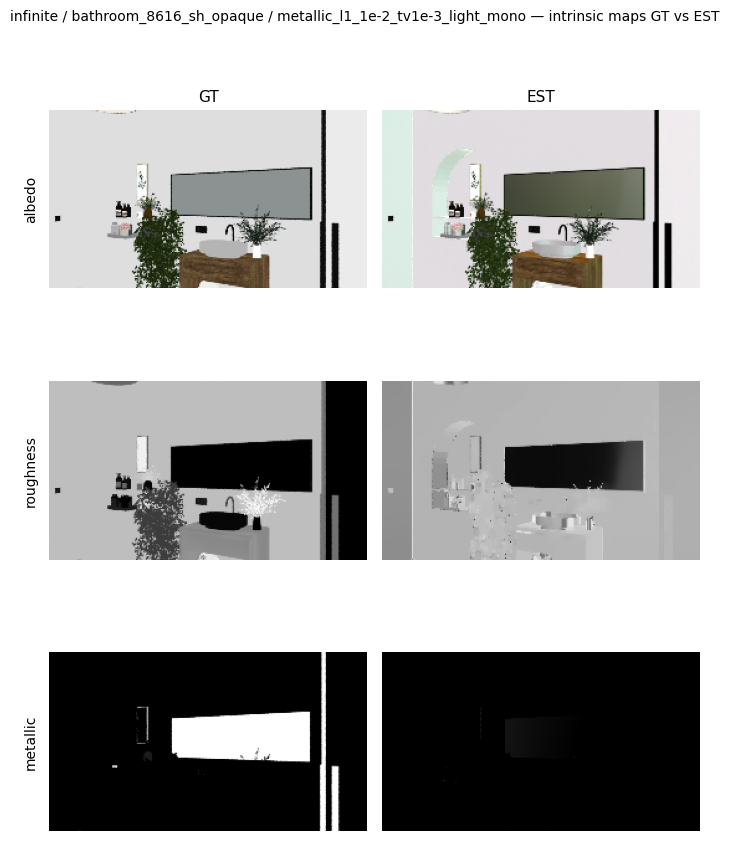

In [21]:
from canonical_relight_render import load_gt_intrinsics, load_est_intrinsics
gt_i  = load_gt_intrinsics(SCENE_DIR, DS)
est_i = load_est_intrinsics(RUN_DIR, scaled=True)
rows = [("albedo",    gt_i["albedo"].clip(0,1),   est_i["albedo"].clip(0,1),   None),
        ("roughness", gt_i["roughness"][...,0],   est_i["roughness"][...,0],   "gray"),
        ("metallic",  gt_i["metallic"][...,0],    est_i["metallic"][...,0],    "gray")]
fig, ax = plt.subplots(len(rows), 2, figsize=(7, 3.1*len(rows)), squeeze=False)
for i,(name,g,e,cm) in enumerate(rows):
    for j,(im,t) in enumerate([(g,"GT"),(e,"EST")]):
        a=ax[i][j]; a.imshow(im, cmap=cm, vmin=0 if cm else None, vmax=1 if cm else None); a.axis("off")
        if i==0: a.set_title(t, fontsize=11)
        if j==0: a.text(-0.08,0.5,name,transform=a.transAxes,rotation=90,va="center",fontsize=10)
fig.suptitle(f"{DATASET} / {SCENE} / {CONFIG} — intrinsic maps GT vs EST", fontsize=10)
plt.tight_layout(); plt.show()

### Training-set fit — observed vs recon vs re-rendered from GT

For a few training lights: the **observed** image, the decomposition's **reconstruction**
(estimated intrinsics + estimated lighting), and the same lighting applied to the **GT
intrinsics** (`GT-render`). The GT-render uses each light's **GT SH** when the dataset has
it (ct_sh_env / infinite); otherwise there is no GT lighting, so it falls back to the
**estimated** per-image SH — isolating the intrinsic difference under identical lighting.

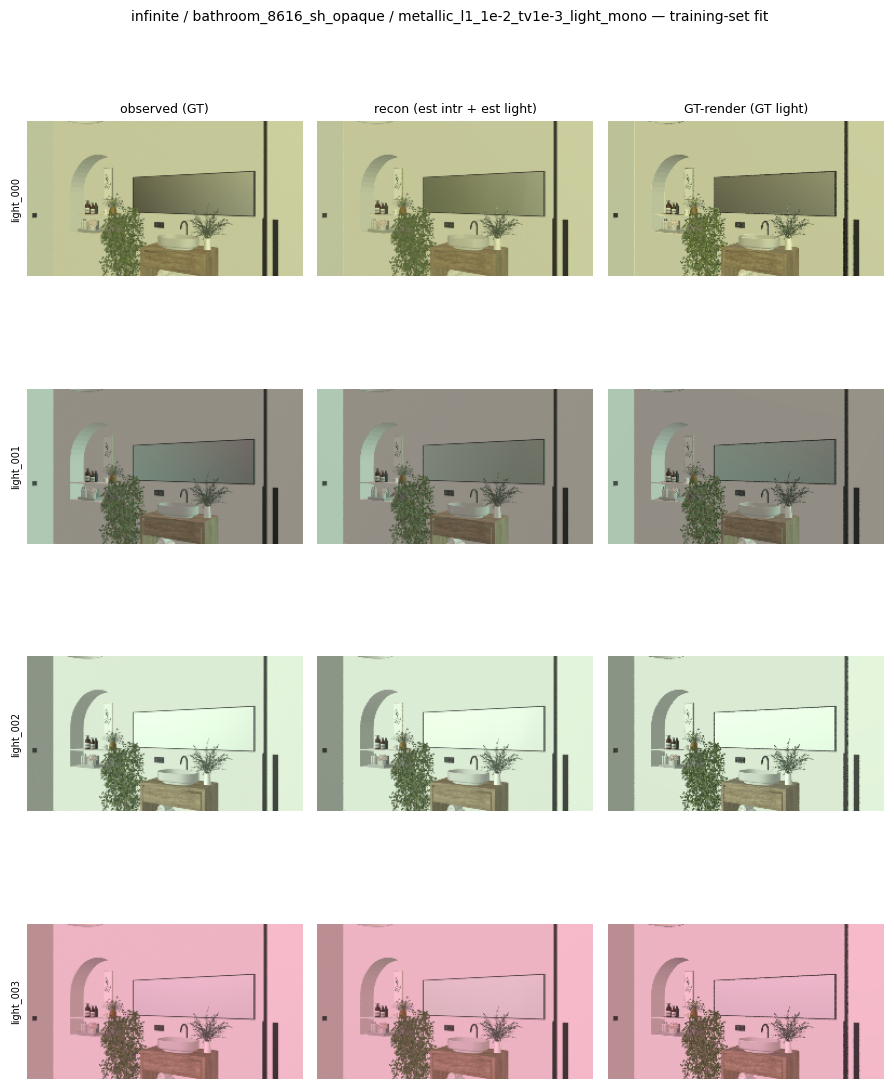

In [22]:
from canonical_relight_render import Relighter, load_gt_intrinsics
from idr.data.scene_io import load_scene

sc   = load_scene(SCENE_DIR, gt_npy=True)
_st  = (lambda a: np.ascontiguousarray(a[::DS, ::DS])) if DS > 1 else (lambda a: a)
gt_i = load_gt_intrinsics(SCENE_DIR, DS)
mask = gt_i["mask"]
rel  = Relighter(gt_i["normals"], mask, DEVICE)

recon_files = sorted((RUN_DIR / "reconstructions").glob("recon_*.npy"))
gt_sh   = sc.get("sh_coeffs")                                   # per-light GT SH, or None
est_sh  = np.load(RUN_DIR / "sh_coeffs_est.npy") if (RUN_DIR / "sh_coeffs_est.npy").exists() else None
have_gt_light = gt_sh is not None
light_src = "GT light" if have_gt_light else "est light"

n = min(4, len(recon_files))
obs   = [_st(sc["images"][i]) for i in range(n)]
recon = [np.load(recon_files[i]) for i in range(n)]
gtrnd = [rel.render_sh(gt_i, (gt_sh[i] if have_gt_light else est_sh[i])) for i in range(n)]

tm_s = float(np.percentile(np.stack(obs)[np.stack([mask]*n)], 99.5)) or 1.0
tm   = lambda x: np.clip(x / tm_s, 0, 1) ** (1/2.2)

fig, ax = plt.subplots(n, 3, figsize=(9, 3.0*n), squeeze=False)
cols = ["observed (GT)", "recon (est intr + est light)", f"GT-render ({light_src})"]
for i in range(n):
    for j, im in enumerate([obs[i], recon[i], gtrnd[i]]):
        a = ax[i][j]; a.imshow(tm(im)); a.axis("off")
        if i == 0: a.set_title(cols[j], fontsize=9)
    ax[i][0].text(-0.06, 0.5, sc["light_keys"][i], transform=ax[i][0].transAxes,
                  rotation=90, va="center", fontsize=7)
fig.suptitle(f"{DATASET} / {SCENE} / {CONFIG} — training-set fit", fontsize=10)
plt.tight_layout(); plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

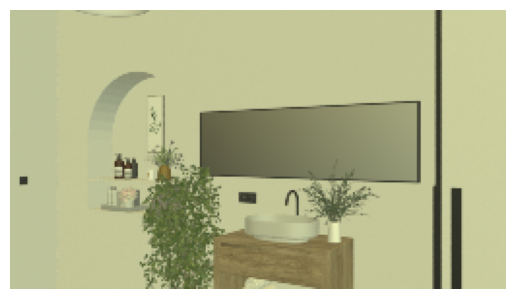

In [23]:
plt.imshow(tm(obs[0]))
plt.axis("off")
plt.show

### Comparison panels — GT-relit vs EST-relit (SH3 and Env-sharp)

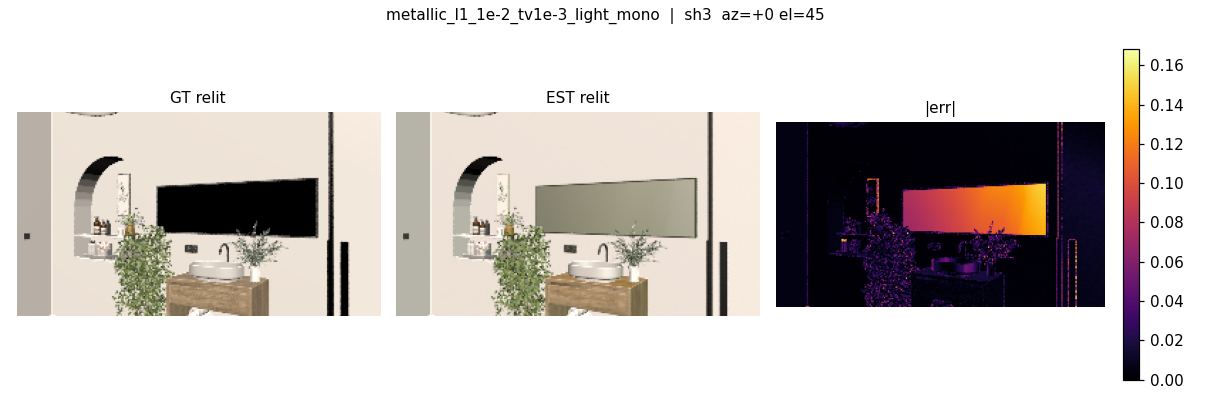

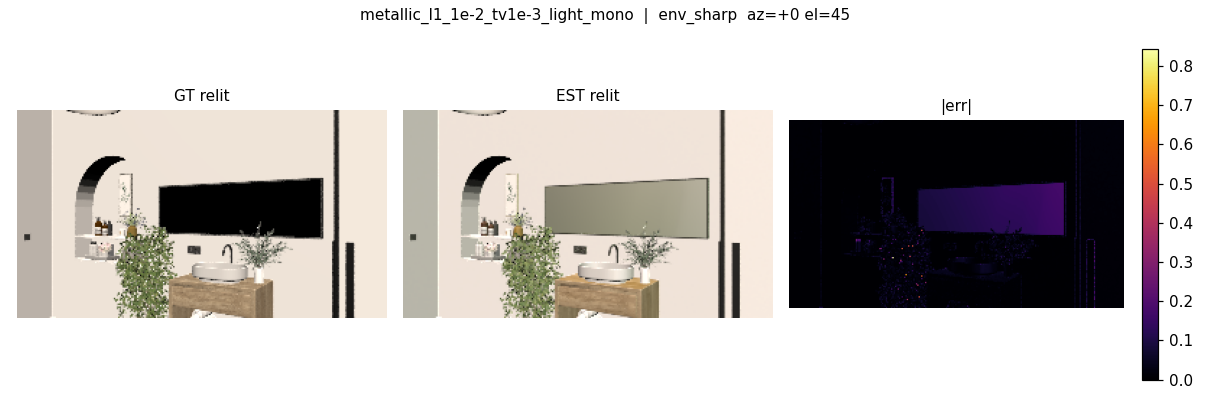

In [24]:
from canonical_relight_render import render_comparison, render_relight_video
from IPython.display import Image as IPyImage, Video, display

for mode in ("sh3", "env_sharp"):
    p = render_comparison(RUN_DIR, SCENE_DIR, mode=mode, az=0.0, el=45.0, ds=DS, device=DEVICE)
    display(IPyImage(filename=p))

### Relight videos — light travels azimuth −45→45 at elevation 45

Two versions: a sharp Env-map highlight, and SH3 (band-limited). mp4 via ffmpeg.

In [25]:
SHOW_VIDEOS = True

if SHOW_VIDEOS:
    paths = []
    for mode in ("env_sharp", "sh3"):
        paths.append(render_relight_video(RUN_DIR, SCENE_DIR, mode=mode, az_from=-45, az_to=45,
                                        elev=45, n_frames=61, ds=DS, device=DEVICE, fps=20))
    for p in paths:
        print(p)
        if p.endswith(".mp4"): display(Video(p, embed=True, width=760))
        else: display(IPyImage(filename=p))

/home/felix/Projects/image-intrinsics/results/canonical_ablation/infinite/bathroom_8616_sh_opaque/metallic_l1_1e-2_tv1e-3_light_mono/relight_env_sharp.mp4


/home/felix/Projects/image-intrinsics/results/canonical_ablation/infinite/bathroom_8616_sh_opaque/metallic_l1_1e-2_tv1e-3_light_mono/relight_sh3.mp4
